# Representative ABM Trajectories

This notebook selects one representative Phase 3 test trajectory per condition. The representative trajectory is the evaluated world whose robustness loss is closest to the median robustness loss across all tested training seeds and evaluation worlds for that condition.

In [10]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

MAX_SHEEP = 400
MAX_WOLF = 400

# Use ["random"], ["evolved"], or ["random", "evolved"].
CONDITIONS_TO_PLOT = ["random", "evolved"]
SEEDS = [1, 2, 3, 4]
EVAL_STEPS = 15000

DATA_ROOT = Path("data")
SAVE_DIR = Path("figures")
SAVE_DIR.mkdir(exist_ok=True)


In [11]:
def condition_paths(condition, seeds=SEEDS):
    if condition not in {"random", "evolved"}:
        raise ValueError("condition must be 'random' or 'evolved'")
    return [DATA_ROOT / condition / f"phase3_{condition}_seed_{seed}" for seed in seeds]


def load_required(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    return np.load(path)


def load_all_test_runs(paths, eval_steps=EVAL_STEPS):
    sheep_all = []
    wolf_all = []
    loss_all = []
    source_all = []

    for path in paths:
        sheep = load_required(path / f"{eval_steps}_sheep_trajs.npy")
        wolf = load_required(path / f"{eval_steps}_wolf_trajs.npy")
        losses = load_required(path / f"{eval_steps}_robustness_losses.npy")

        if sheep.shape != wolf.shape:
            raise ValueError(f"Sheep/wolf trajectory shapes differ in {path}: {sheep.shape} vs {wolf.shape}")
        if sheep.shape[0] != losses.shape[0]:
            raise ValueError(f"Trajectory/loss count differs in {path}: {sheep.shape[0]} vs {losses.shape[0]}")

        sheep_all.append(sheep)
        wolf_all.append(wolf)
        loss_all.append(losses)
        source_all.extend((path, run_idx) for run_idx in range(losses.shape[0]))

    return (
        np.concatenate(sheep_all, axis=0),
        np.concatenate(wolf_all, axis=0),
        np.concatenate(loss_all, axis=0),
        source_all,
    )


def representative_index(losses):
    median_loss = np.median(losses)
    return int(np.argmin(np.abs(losses - median_loss)))


In [12]:
def plot_representative_trajectory(condition, eval_steps=EVAL_STEPS):
    paths = condition_paths(condition)
    sheep_trajs, wolf_trajs, losses, sources = load_all_test_runs(paths, eval_steps)

    idx = representative_index(losses)
    selected_path, selected_run_idx = sources[idx]
    median_loss = np.median(losses)
    selected_loss = losses[idx]

    sheep_pop = sheep_trajs[idx]
    wolf_pop = wolf_trajs[idx]
    t = np.arange(len(sheep_pop))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t, sheep_pop, label="Sheep", color="forestgreen", linewidth=1.8)
    ax.plot(t, wolf_pop, label="Wolves", color="firebrick", linewidth=1.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(MAX_SHEEP, color="forestgreen", linestyle="--", linewidth=1, alpha=0.35)
    ax.axhline(MAX_WOLF, color="firebrick", linestyle="--", linewidth=1, alpha=0.35)
    ax.set_ylim(-10, max(MAX_SHEEP, MAX_WOLF) + 20)
    # ax.set_xlabel("Timestep")
    # ax.set_ylabel("Active agents")
    # ax.set_title(f"Representative ABM trajectory: {condition.capitalize()} agents")
    # ax.legend(frameon=False)
    # Set axis label sizes to 15
    ax.set_xlabel("Timestep", fontsize=15)
    ax.set_ylabel("Active agents", fontsize=15)

    # Optional: You can also bump up the title size if you want it to match
    ax.set_title(f"ABM trajectory: {condition.capitalize()} agents", fontsize=18)

    # Add tick params size 12
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Set legend text size to 18
    ax.legend(frameon=False, fontsize=18)

    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    output_path = SAVE_DIR / f"representative_abm_{condition}.svg"
    fig.savefig(output_path, bbox_inches="tight")

    print(f"{condition.capitalize()} agents")
    print(f"  saved: {output_path}")
    print(f"  selected source: {selected_path}")
    print(f"  selected eval-world index in source: {selected_run_idx}")
    print(f"  selected loss: {selected_loss:.2f}")
    print(f"  median loss across all loaded trajectories: {median_loss:.2f}")
    print(f"  loaded trajectories: {len(losses)} from {len(paths)} training seeds")

    return fig, ax


Random agents
  saved: figures/representative_abm_random.svg
  selected source: data/random/phase3_random_seed_3
  selected eval-world index in source: 5
  selected loss: 286.00
  median loss across all loaded trajectories: 287.23
  loaded trajectories: 64 from 4 training seeds
Evolved agents
  saved: figures/representative_abm_evolved.svg
  selected source: data/evolved/phase3_evolved_seed_1
  selected eval-world index in source: 3
  selected loss: 65.91
  median loss across all loaded trajectories: 66.53
  loaded trajectories: 64 from 4 training seeds


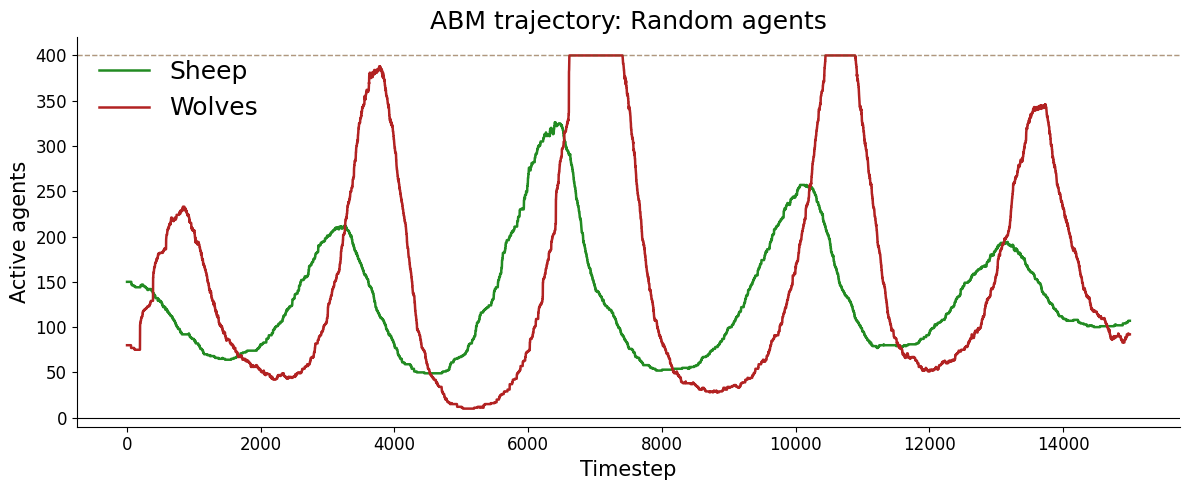

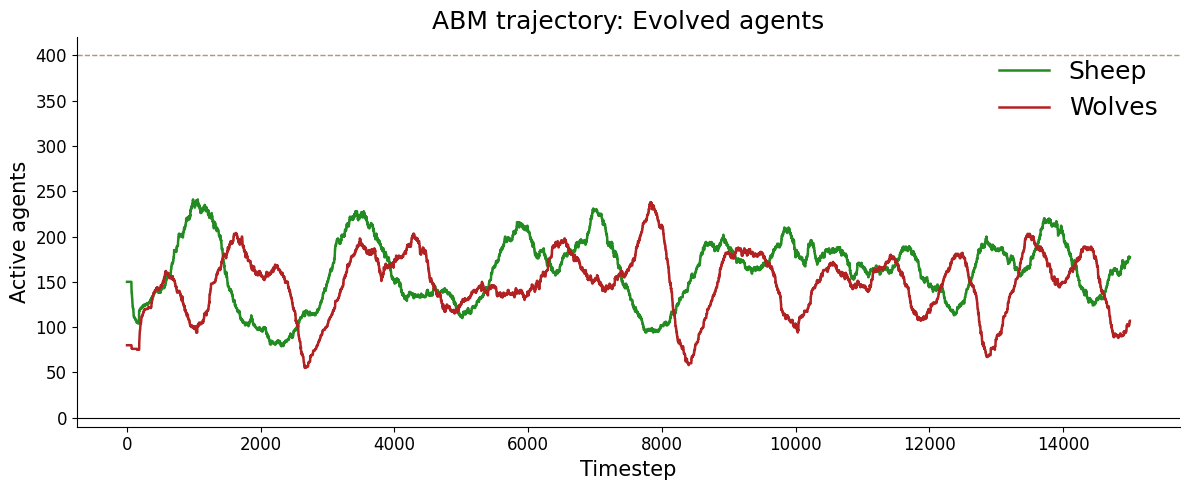

In [13]:
for condition in CONDITIONS_TO_PLOT:
    plot_representative_trajectory(condition)


Saved figures/representative_abm_random_vs_evolved.svg


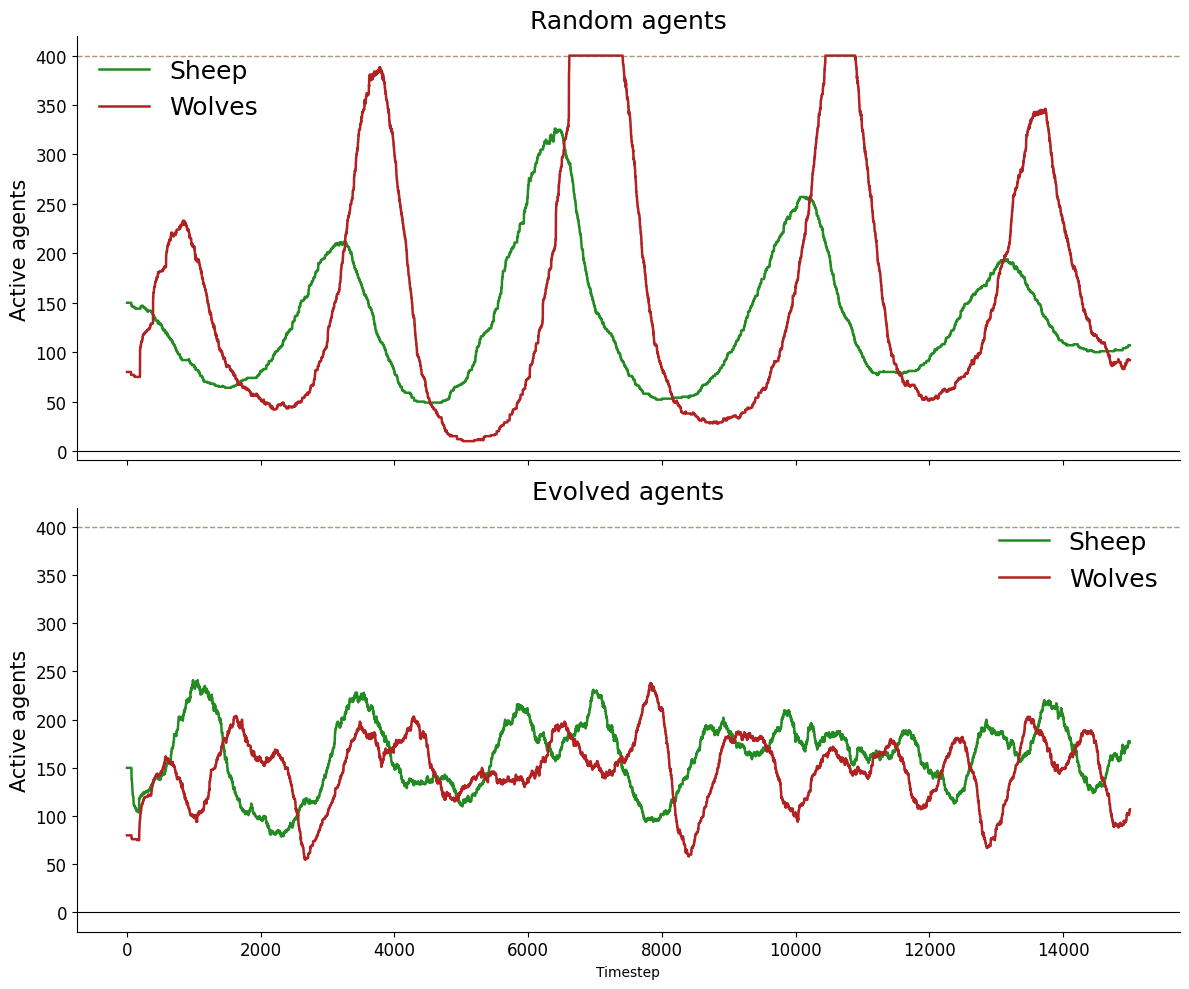

In [14]:
# Optional: plot both representative trajectories in one figure.
def plot_representative_comparison(conditions=CONDITIONS_TO_PLOT, eval_steps=EVAL_STEPS):
    fig, axes = plt.subplots(len(conditions), 1, figsize=(12, 5 * len(conditions)), sharex=True)
    if len(conditions) == 1:
        axes = [axes]

    for ax, condition in zip(axes, conditions):
        paths = condition_paths(condition)
        sheep_trajs, wolf_trajs, losses, sources = load_all_test_runs(paths, eval_steps)
        idx = representative_index(losses)
        sheep_pop = sheep_trajs[idx]
        wolf_pop = wolf_trajs[idx]
        t = np.arange(len(sheep_pop))

        ax.plot(t, sheep_pop, label="Sheep", color="forestgreen", linewidth=1.8)
        ax.plot(t, wolf_pop, label="Wolves", color="firebrick", linewidth=1.8)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axhline(MAX_SHEEP, color="forestgreen", linestyle="--", linewidth=1, alpha=0.35)
        ax.axhline(MAX_WOLF, color="firebrick", linestyle="--", linewidth=1, alpha=0.35)
        # ax.set_ylim(-10, max(MAX_SHEEP, MAX_WOLF) + 20)
        # ax.set_ylabel("Active agents")
        # ax.set_title(f"{condition.capitalize()} agents")
        # ax.legend(frameon=False)
        # ax.spines[["top", "right"]].set_visible(False)
        ax.set_ylabel("Active agents", fontsize=15)
        ax.set_title(f"{condition.capitalize()} agents", fontsize=18)

        # Add tick marks inside the loop
        ax.tick_params(axis='both', which='major', labelsize=12)

        ax.legend(frameon=False, fontsize=18)
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel("Timestep")
    fig.tight_layout()

    condition_tag = "_vs_".join(conditions)
    output_path = SAVE_DIR / f"representative_abm_{condition_tag}.svg"
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig, axes

if len(CONDITIONS_TO_PLOT) > 1:
    plot_representative_comparison()
